In [ ]:
import numpy as np
from pricing.BSMgreeks import CallDelta, CallOption
import matplotlib.pyplot as plt
from pricing.GBMPriceSim import stock_full_GBM
from pricing.OptionsPrice import FourierPricing, F_call_price_Lewis, char_BSM, char_Jump


In [88]:
import importlib
import pricing.OptionsPrice

importlib.reload(pricing.OptionsPrice)

print(dir(pricing.OptionsPrice))

['BSM_call_price', 'CallOption', 'F_call_price_Lewis', 'FourierPricing', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'char_BSM', 'char_Jump', 'np', 'plt', 'scpint']


### Volatility-Delta hedging with brownian motion; hedging with implied and actual volatility
Literature: Paul Wilmott on Qunatitative Finance, Paul Wilmott. Chapter 12

Our goal here is to extend the discussion of this chapter to jump processes. We begin by first coding the math presented in the book, then connecting it to the jump process extension for this BSM model.




In [ ]:
### Delta hedging of a call option:

#Strategy:
# We sell a call option and hedge the position by buying delta shares of the underlying stock. The PnL of the hedged position is given by:

#We define a class as we want to keep most parameters the same for by-testing, while changing 
# volatility used in the delta, the method used for calculating the price of a call, or changing the
# simulation situation.
class VolatilityHedge:
    def __init__(self, S0, K, T, r, D, sigma_a, sigma_i, N, stock_sim, F_method=False, char_func = None, mu_J=None, delta_J=None, lambd=None):
        '''
        S0: initial stock price
        K: strike price
        T: time to maturity
        r: risk-free interest rate
        D: dividend yield
        sigma_a: realised volatility of the stock
        sigma_i: implied volatility of the option
        N: number of time steps
        mu_J: mean log jump size
        delta_J: variability of jump size
        lambd: jump intensity
        stock_sim: type of simulation to run for stock price generation
        F_method: whether to use Fourier method for option pricing
        char_func: characteristic function for Fourier method
        mu_J: mean log jump size
        delta_J: variability of jump size
        lambd: jump intensity
        '''
        self.S0 = S0
        self.K = K
        self.T = T
        self.r = r
        self.D = D
        self.sigma_a = sigma_a
        self.sigma_i = sigma_i
        self.N = N
        self.stock_sim = stock_sim
        self.F_method = F_method
        self.mu_J = mu_J
        self.delta_J = delta_J
        self.lambd = lambd
        self.char_func = char_func

    def hedge_simulation(self, sigma_hedge, call_option, call_delta):
        '''
        sigma_hedge: volatility used to compute delta
        call_option: function to compute the call option price
        call_delta: function to compute the delta of the call option
        '''


        # If we use a fourier method, we create a function that takes the jump diffusion
        # parameters directly as given when the class is initialised. Thus enabling us to
        # minimize the amount of parameters .hedge_simulation needs. We thus include fourier
        # methods without being invasive to simpler methods of pricing.
        if self.F_method == True:
            call_option_class = FourierPricing(call_option, self.char_func, self.mu_J, self.delta_J, self.lambd).price
        else:
            call_option_class = call_option

        dt = self.T/self.N
        t = np.linspace(0, self.T, self.N+1)
        PnL = np.zeros(self.N+1)
        S = self.stock_sim(self.S0, self.r, self.sigma_a, dt, self.T)
        call_price_temp = call_option_class(S[0], self.sigma_i, self.D, self.r, self.K, self.T)

        for j in range(self.N):
            call_price = call_option_class(S[j+1], self.sigma_i, self.D, self.r, self.K, self.T - t[j+1])

            dV = call_price - call_price_temp
            delta = call_delta(S[j], sigma_hedge, self.D, self.r, self.K, self.T - t[j])

            gain = delta * (S[j+1] - S[j]) - dV +  delta * self.D * S[j] * dt
            PnL[j+1] = PnL[j] + gain

            call_price_temp = call_price
    
        return PnL, S, t



#### Examples Of Use

In [104]:
#Creating our hedge simulation:


#Params
S0 = 100
K = 110
T = 1
r = 0.05
D = 0.0
sigma_a = 0.20
sigma_i = 0.30
N = 252


BSM_Hedge = VolatilityHedge(S0, K, T, r, D, sigma_a, sigma_i, N, stock_full_GBM)

#Number of simulations to run
n_simulations = 50


c:\Users\nikit\Projects\tr_al\strategies\pricing\BSMgreeks.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  return x_num/x_den


Mean PnL for hedging with actual volatility over 50 simulations:  6.590260896099527
Std PnL for hedging with actual volatility over 50 simulations:  1.430511193764528


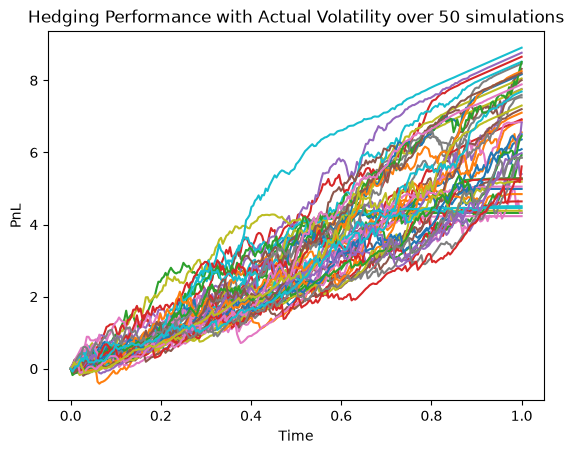

Mean PnL for hedging with implied volatility:  6.464535678066078
Std PnL for hedging with implied volatility:  2.002219041082614


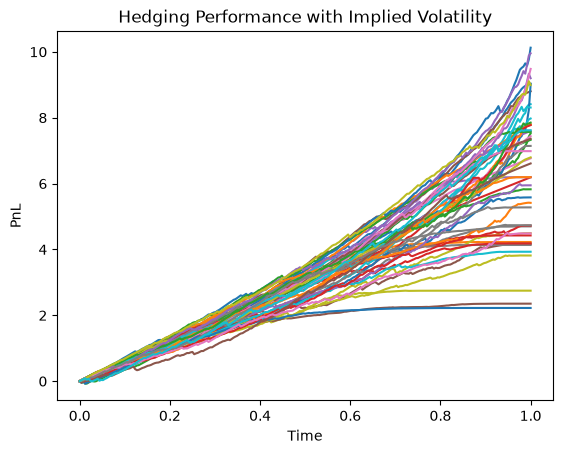

In [112]:
### Examples

# Hedging with actual volatility

plt.figure()
#Simulation parameters
final_pnl1 = np.zeros(n_simulations)
    
for j in range(n_simulations):
    pnl1, S1, t1 = BSM_Hedge.hedge_simulation(sigma_a, CallOption, CallDelta)
    plt.plot(t1, pnl1)
    final_pnl1[j] = pnl1[-1]

mean_pnl1 = np.mean(final_pnl1)
std_pnl1 = np.std(final_pnl1)
print(f"Mean PnL for hedging with actual volatility over {n_simulations} simulations: ", mean_pnl1)
print(f"Std PnL for hedging with actual volatility over {n_simulations} simulations: ", std_pnl1)
plt.xlabel('Time')
plt.ylabel('PnL')
plt.title(f"Hedging Performance with Actual Volatility over {n_simulations} simulations")
plt.show()



# Hedging with implied volatility

#same params as above

plt.figure()
#Simulation parameters
final_pnl2 = np.zeros(n_simulations)


for j in range(n_simulations):
    pnl2, S2, t2 = BSM_Hedge.hedge_simulation(sigma_i, CallOption, CallDelta)
    plt.plot(t2, pnl2)
    final_pnl2[j] = pnl2[-1]

mean_pnl2 = np.mean(final_pnl2)
std_pnl2 = np.std(final_pnl2)
print("Mean PnL for hedging with implied volatility: ", mean_pnl2)
print("Std PnL for hedging with implied volatility: ", std_pnl2)
plt.xlabel('Time')
plt.ylabel('PnL')
plt.title('Hedging Performance with Implied Volatility')
plt.show()


Mean PnL for hedging with actual volatility over 50 simulations:  3.6620394303346755
Std PnL for hedging with actual volatility over 50 simulations:  1.2051626220320963


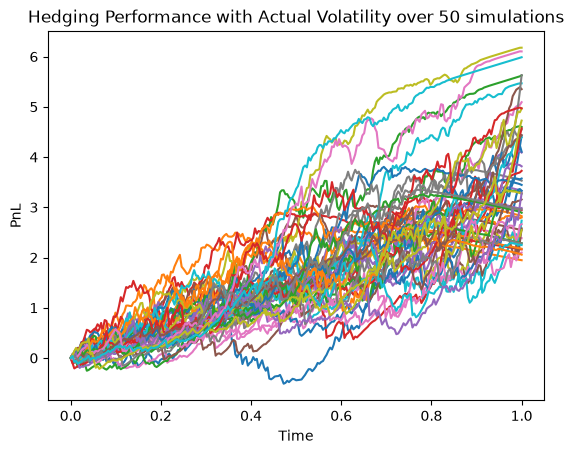

In [113]:
# Hedging with actual volatility but using the FOURIER method!

BSM_Hedge_fourier = VolatilityHedge(S0, K, T, r, D, sigma_a, sigma_i, N, stock_full_GBM, F_method=True, char_func=char_BSM)

plt.figure()
#Simulation parameters
final_pnl3 = np.zeros(n_simulations)
    
for j in range(n_simulations):
    pnl3, S3, t3 = BSM_Hedge_fourier.hedge_simulation(sigma_a, F_call_price_Lewis, CallDelta)
    plt.plot(t3, pnl3)
    final_pnl3[j] = pnl3[-1]

mean_pnl3 = np.mean(final_pnl3)
std_pnl3 = np.std(final_pnl3)
print(f"Mean PnL for hedging with actual volatility over {n_simulations} simulations: ", mean_pnl3)
print(f"Std PnL for hedging with actual volatility over {n_simulations} simulations: ", std_pnl3)
plt.xlabel('Time')
plt.ylabel('PnL')
plt.title(f"Hedging Performance with Actual Volatility over {n_simulations} simulations")
plt.show()

